In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('Datasets/Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [5]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

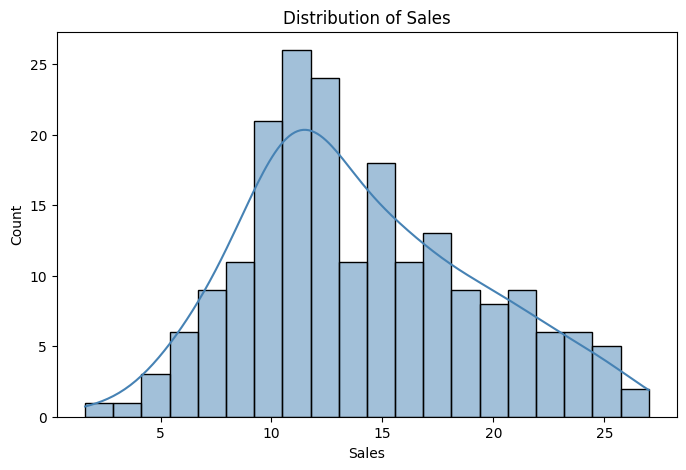

In [6]:
# Drop the useless index column
df = df.drop('Unnamed: 0', axis=1)

# Check distribution of Sales
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Sales')
plt.show()

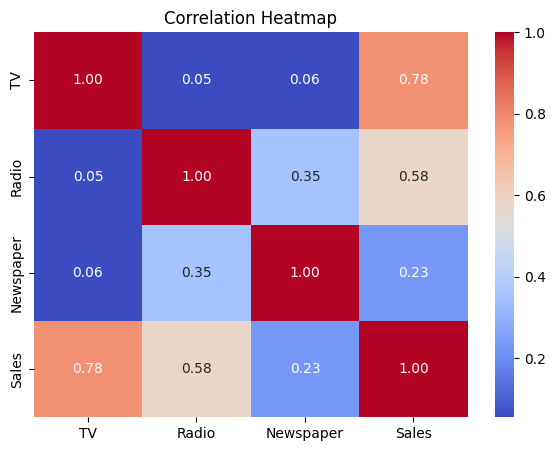

In [7]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

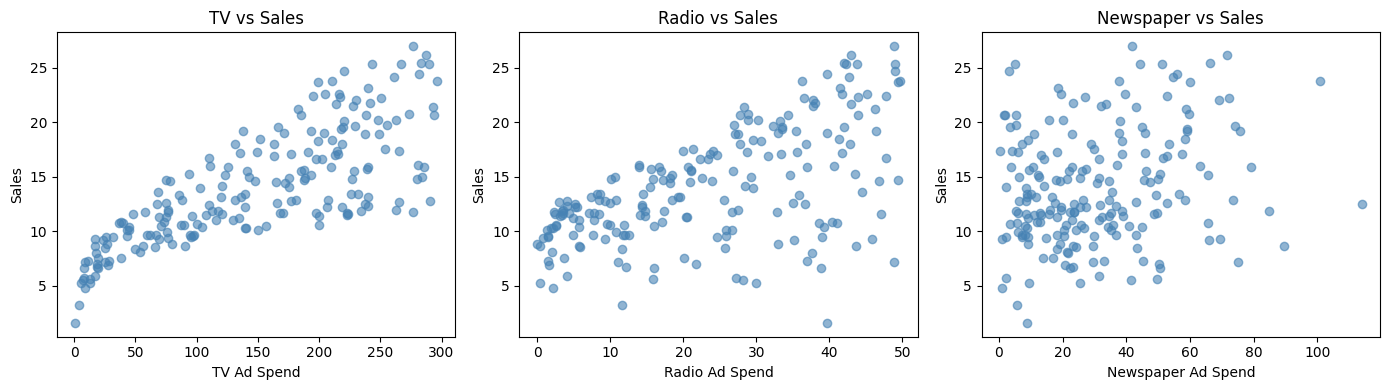

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper']):
    ax.scatter(df[col], df['Sales'], alpha=0.6, color='steelblue')
    ax.set_xlabel(f'{col} Ad Spend')
    ax.set_ylabel('Sales')
    ax.set_title(f'{col} vs Sales')

plt.tight_layout()
plt.show()

In [9]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")
print(f"Intercept: {model.intercept_:.3f}")
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f" {feature}: {coef: .4f}")

Model trained!
Intercept: 2.979
Coefficients:
 TV:  0.0447
 Radio:  0.1892
 Newspaper:  0.0028


In [10]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae: .2f}")
print(f"RMSE: {rmse: .2f}")
print(f"R²:   {r2:.3f}")

MAE:  1.46
RMSE:  1.78
R²:   0.899


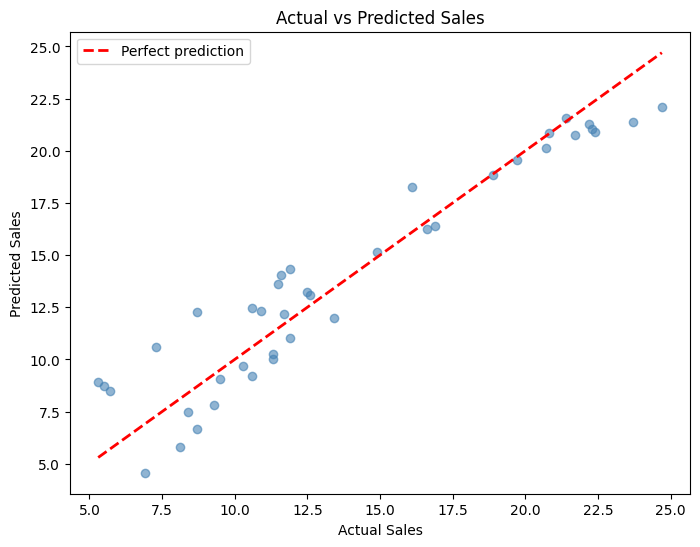

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print(f"Random Forest R²: {r2_score(y_test, rf_pred):.3f}")
print(f"Linear Regression R² {r2:.3f}")

Random Forest R²: 0.981
Linear Regression R² 0.899


In [14]:
df['TV_Radio'] = df['TV'] * df['Radio']

In [15]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"CV R² scores: {scores}")
print(f"Mean R²: {scores.mean():.3f} (+/- {scores.std():.3f})")

CV R² scores: [0.87865198 0.91763212 0.92933032 0.81443904 0.89547829]
Mean R²: 0.887 (+/- 0.040)


In [16]:
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f"Random Forest CV R² scores: {rf_scores}")
print(f"Mean R²: {rf_scores.mean():.3f} (+/- {rf_scores.std():.3f})")

Random Forest CV R² scores: [0.9796078  0.98711934 0.96638271 0.96153693 0.98180592]
Mean R²: 0.975 (+/- 0.010)


In [17]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

gb_scores = cross_val_score(gb_model, X, y, cv=5, scoring='r2')

print(f"Gradient Boosting R²: {r2_score(y_test, gb_pred):.3f}")
print(f"CV Mean R²: {gb_scores.mean():.3f} (+/- {gb_scores.std():.3f})")

Gradient Boosting R²: 0.983
CV Mean R²: 0.978 (+/- 0.009)


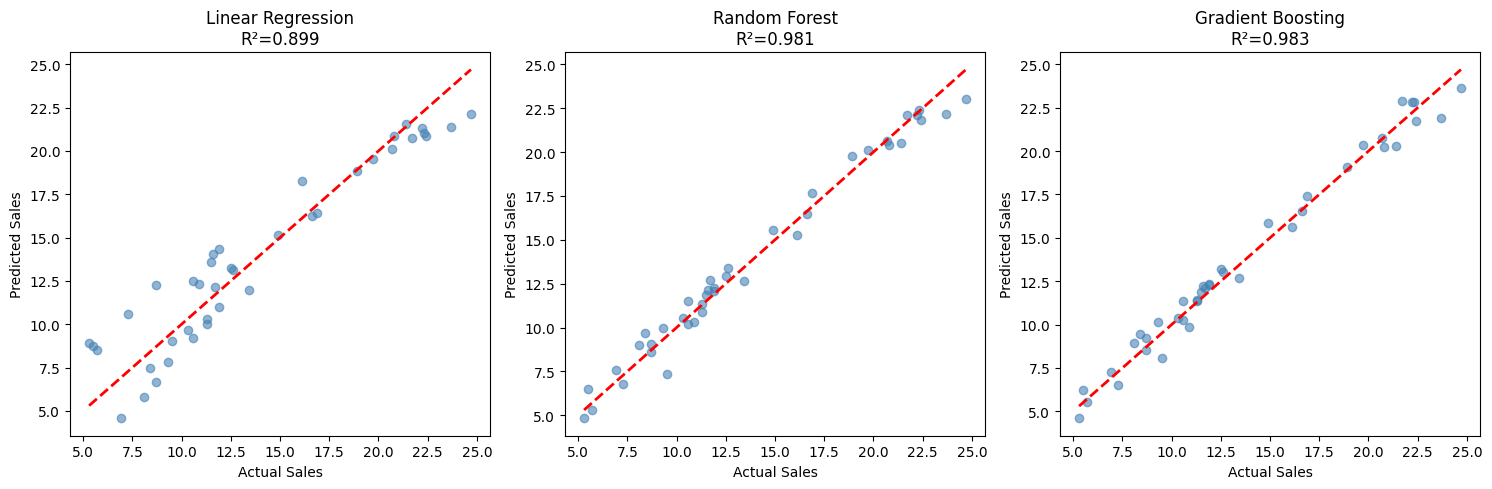

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_preds = [
    ('Linear Regression', y_pred),
    ('Random Forest', rf_pred),
    ('Gradient Boosting', gb_pred)
]

for ax, (name, pred) in zip(axes, models_preds):
    ax.scatter(y_test, pred, alpha=0.6, color='steelblue')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=2)
    ax.set_xlabel('Actual Sales')
    ax.set_ylabel('Predicted Sales')
    ax.set_title(f'{name}\nR²={r2_score(y_test, pred):.3f}')

plt.tight_layout()
plt.show()
    